# MLOPS - Actividad Dataset - Notebook

* **Angel Irwin Briseño Fierro** A01796844

Para el desarrollo de esta practica se utilizará el dataset "Adaptive PLC Automation Dataset" de Kaggle: https://www.kaggle.com/datasets/colabsss/adaptive-plc-automation-dataset

Los datos que contiene dicho dataset presenta las actividades operacionales relacionadas con systemas PLC (programmable logic controller), interacciones con operadores, adaptacion en la produccion entre otros valores que seran analizados a continuacion.

El objetivo de esta practica, con el conjunto de datos seleccionado, es predecir que tipo de reconfiguracion se obtiene en el marco de adaptabilidad, cuyo campo es llamado "Reconfiguration_Status" (Unsafe_Configuration,Operator_Review_Required, Reconfiguration_Failed, Successful_Reconfiguration).

In [ ]:
#Carga de librerias necesarias
import pandas as pd
import numpy as np
import sklearn as skl
import mlflow as mlf
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
#Lectura de datos y muestra de datos
initDf = pd.read_csv("./adaptativePLC/Human_Machine_Adaptive_PLC_Reconfiguration_Dataset.csv")
initDf.head(10)

,Record_ID,Product_Type,Production_Mode,Machine_ID,PLC_Controller_Type,Task_ID,Task_Complexity_Level,Machine_Load_Percent,Sensor_Error_Rate,Human_Operator_ID,...,Digital_Twin_Safety_Score,Simulation_Cycle_Time_Sec,Energy_Consumption_kWh,Throughput_Units_Per_Hour,Downtime_Min,Safety_Risk_Level,Adaptability_Index,Human_Intervention_Count,Decision_Accuracy_Percent,Reconfiguration_Status
0,REC_00001,Automotive_Part,Batch,MCH_089,Mitsubishi_FX,TASK_0049,7,85.18,1.64,OP_059,...,65.42,44.93,16.45,52.01,17.13,Medium,64.56,5,68.36,Operator_Review_Required
1,REC_00002,Automotive_Part,Batch,MCH_081,Schneider_Modicon,TASK_0420,3,59.10,8.36,OP_050,...,48.62,54.01,12.51,120.13,5.03,Low,69.22,5,76.26,Unsafe_Configuration
2,REC_00003,Automotive_Part,Flexible,MCH_060,Allen_Bradley,TASK_0380,4,54.64,4.47,OP_041,...,80.29,86.34,31.54,125.14,17.60,Medium,88.17,0,88.92,Successful_Reconfiguration
3,REC_00004,Custom_Component,Job_Shop,MCH_091,Allen_Bradley,TASK_0035,9,97.17,6.59,OP_101,...,53.71,60.81,32.51,132.87,19.74,High,75.63,5,80.74,Unsafe_Configuration
4,REC_00005,Automotive_Part,Flexible,MCH_071,Omron_CP,TASK_0187,1,80.47,2.08,OP_086,...,65.76,35.70,23.16,173.00,14.86,Medium,69.52,7,76.14,Operator_Review_Required
5,REC_00006,Electronic_Module,Mass_Customization,MCH_037,Siemens_S7,TASK_0225,2,74.33,2.58,OP_051,...,65.81,45.44,19.39,63.64,20.02,Low,79.54,5,85.89,Reconfiguration_Failed
6,REC_00007,Medical_Device,Mass_Customization,MCH_002,Schneider_Modicon,TASK_0053,8,94.40,2.81,OP_068,...,53.30,68.70,13.15,66.16,37.25,Critical,56.70,2,57.33,Unsafe_Configuration
7,REC_00008,Custom_Component,Batch,MCH_052,Omron_CP,TASK_0489,8,49.97,6.22,OP_128,...,41.16,47.52,30.04,161.71,18.46,High,67.53,6,74.74,Unsafe_Configuration
8,REC_00009,Custom_Component,Mass_Customization,MCH_019,Schneider_Modicon,TASK_0304,2,87.78,5.78,OP_131,...,56.03,86.29,38.94,147.96,12.17,Low,72.90,2,76.00,Operator_Review_Required
9,REC_00010,Automotive_Part,Flexible,MCH_014,Mitsubishi_FX,TASK_0277,8,60.48,7.56,OP_048,...,49.91,82.89,29.05,56.37,23.37,Low,74.96,0,81.83,Unsafe_Configuration


In [ ]:
#Verificando los tipos de datos
initDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Record_ID                           11500 non-null  object 
 1   Product_Type                        11500 non-null  object 
 2   Production_Mode                     11500 non-null  object 
 3   Machine_ID                          11500 non-null  object 
 4   PLC_Controller_Type                 11500 non-null  object 
 5   Task_ID                             11500 non-null  object 
 6   Task_Complexity_Level               11500 non-null  int64  
 7   Machine_Load_Percent                11500 non-null  float64
 8   Sensor_Error_Rate                   11500 non-null  float64
 9   Human_Operator_ID                   11500 non-null  object 
 10  Operator_Experience_Level           11500 non-null  object 
 11  Manual_Programming_Time_Min         11500

In [36]:
#Eliminación inicial de columnas que no ofrecen información no necesaria en este caso los IDs.
cols=[
    "Record_ID",
    "Human_Operator_ID",
    "Task_ID",
    "Machine_ID"
]
df=initDf.drop(columns=[col for col in cols if col in initDf.columns])
df.head()

,Product_Type,Production_Mode,PLC_Controller_Type,Task_Complexity_Level,Machine_Load_Percent,Sensor_Error_Rate,Operator_Experience_Level,Manual_Programming_Time_Min,Previous_Reconfiguration_Time_Min,Knowledge_Graph_Dependency_Count,...,Digital_Twin_Safety_Score,Simulation_Cycle_Time_Sec,Energy_Consumption_kWh,Throughput_Units_Per_Hour,Downtime_Min,Safety_Risk_Level,Adaptability_Index,Human_Intervention_Count,Decision_Accuracy_Percent,Reconfiguration_Status
0,Automotive_Part,Batch,Mitsubishi_FX,7,85.18,1.64,Medium,152.07,83.72,9,...,65.42,44.93,16.45,52.01,17.13,Medium,64.56,5,68.36,Operator_Review_Required
1,Automotive_Part,Batch,Schneider_Modicon,3,59.10,8.36,Expert,246.73,128.68,26,...,48.62,54.01,12.51,120.13,5.03,Low,69.22,5,76.26,Unsafe_Configuration
2,Automotive_Part,Flexible,Allen_Bradley,4,54.64,4.47,Low,185.59,176.67,11,...,80.29,86.34,31.54,125.14,17.60,Medium,88.17,0,88.92,Successful_Reconfiguration
3,Custom_Component,Job_Shop,Allen_Bradley,9,97.17,6.59,Expert,113.44,98.98,13,...,53.71,60.81,32.51,132.87,19.74,High,75.63,5,80.74,Unsafe_Configuration
4,Automotive_Part,Flexible,Omron_CP,1,80.47,2.08,High,90.34,200.89,15,...,65.76,35.70,23.16,173.00,14.86,Medium,69.52,7,76.14,Operator_Review_Required


In [37]:
print(df.isnull().sum())

Product_Type                          0
Production_Mode                       0
PLC_Controller_Type                   0
Task_Complexity_Level                 0
Machine_Load_Percent                  0
Sensor_Error_Rate                     0
Operator_Experience_Level             0
Manual_Programming_Time_Min           0
Previous_Reconfiguration_Time_Min     0
Knowledge_Graph_Dependency_Count      0
Machine_Task_Dependency_Score         0
Product_Customization_Level           0
System_State_Complexity               0
Double_DQN_Action_ID                  0
DQN_Confidence_Score                  0
Predicted_Reconfiguration_Time_Min    0
XAI_Explanation_Score                 0
Operator_Validation_Status            0
Operator_Trust_Score                  0
Auto_Code_Generation_Time_Sec         0
PLC_Code_Error_Count                  0
Digital_Twin_Safety_Score             0
Simulation_Cycle_Time_Sec             0
Energy_Consumption_kWh                0
Throughput_Units_Per_Hour             0


In [38]:
print(df.shape)

(11500, 31)


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Product_Type                        11500 non-null  object 
 1   Production_Mode                     11500 non-null  object 
 2   PLC_Controller_Type                 11500 non-null  object 
 3   Task_Complexity_Level               11500 non-null  int64  
 4   Machine_Load_Percent                11500 non-null  float64
 5   Sensor_Error_Rate                   11500 non-null  float64
 6   Operator_Experience_Level           11500 non-null  object 
 7   Manual_Programming_Time_Min         11500 non-null  float64
 8   Previous_Reconfiguration_Time_Min   11500 non-null  float64
 9   Knowledge_Graph_Dependency_Count    11500 non-null  int64  
 10  Machine_Task_Dependency_Score       11500 non-null  float64
 11  Product_Customization_Level         11500

In [40]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Type,11500,5,Automotive_Part,2372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production_Mode,11500,4,Job_Shop,2948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLC_Controller_Type,11500,5,Mitsubishi_FX,2344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Task_Complexity_Level,11500.0,NaN,NaN,NaN,5.529826,2.881109,1.0,3.0,6.0,8.0,10.0
Machine_Load_Percent,11500.0,NaN,NaN,NaN,66.430266,18.171156,35.01,50.8175,66.28,82.19,97.99
Sensor_Error_Rate,11500.0,NaN,NaN,NaN,4.318142,2.430623,0.1,2.18,4.34,6.39,8.5
Operator_Experience_Level,11500,4,Low,2929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Manual_Programming_Time_Min,11500.0,NaN,NaN,NaN,176.33415,58.612911,51.29,127.5425,176.675,224.9775,299.43
Previous_Reconfiguration_Time_Min,11500.0,NaN,NaN,NaN,128.957361,43.359533,39.25,92.73,128.795,164.9625,219.97
Knowledge_Graph_Dependency_Count,11500.0,NaN,NaN,NaN,15.554,8.077972,2.0,9.0,16.0,23.0,29.0


In [56]:
#Numerical Columns:
numCols = df.select_dtypes(include=np.number).columns #['Task_Complexity_Level', 'Machine_Load_Percent', 'Sensor_Error_Rate', 'Manual_Programming_Time_Min', 'Previous_Reconfiguration_Time_Min', 'Product_Customization_Level', 'Double_DQN_Action_ID', 'DQN_Confidence_Score', 'Auto_Code_Generation_Time_Sec', 'PLC_Code_Error_Count', 'Digital_Twin_Safety_Score', 'Simulation_Cycle_Time_Sec', 'Energy_Consumption_kWh', 'Throughput_Units_Per_Hour', 'Downtime_Min', 'Adaptability_Index', 'Human_Intervention_Count']

#Categorical Columns:
catCols = df.select_dtypes(exclude=np.number).columns #['Product_Type', 'Production_Mode', 'PLC_Controller_Type', 'Operator_Experience_Level', 'Safety_Risk_Level','Reconfiguration_Status']

In [55]:
# Outlier counts using IQR
Q1=df[numCols].quantile(0.25)
Q3=df[numCols].quantile(0.75)
IQR=Q3-Q1
outliers=((df[numCols]<(Q1-1.5*IQR))|(df[numCols]>(Q3+1.5*IQR)))
outliers.sum().sort_values(ascending=False)

Digital_Twin_Safety_Score             19
Predicted_Reconfiguration_Time_Min    18
Adaptability_Index                     1
Task_Complexity_Level                  0
Previous_Reconfiguration_Time_Min      0
Machine_Load_Percent                   0
Sensor_Error_Rate                      0
Manual_Programming_Time_Min            0
Product_Customization_Level            0
Machine_Task_Dependency_Score          0
Knowledge_Graph_Dependency_Count       0
System_State_Complexity                0
XAI_Explanation_Score                  0
Operator_Trust_Score                   0
Double_DQN_Action_ID                   0
DQN_Confidence_Score                   0
PLC_Code_Error_Count                   0
Auto_Code_Generation_Time_Sec          0
Energy_Consumption_kWh                 0
Simulation_Cycle_Time_Sec              0
Throughput_Units_Per_Hour              0
Downtime_Min                           0
Human_Intervention_Count               0
Decision_Accuracy_Percent              0
dtype: int64

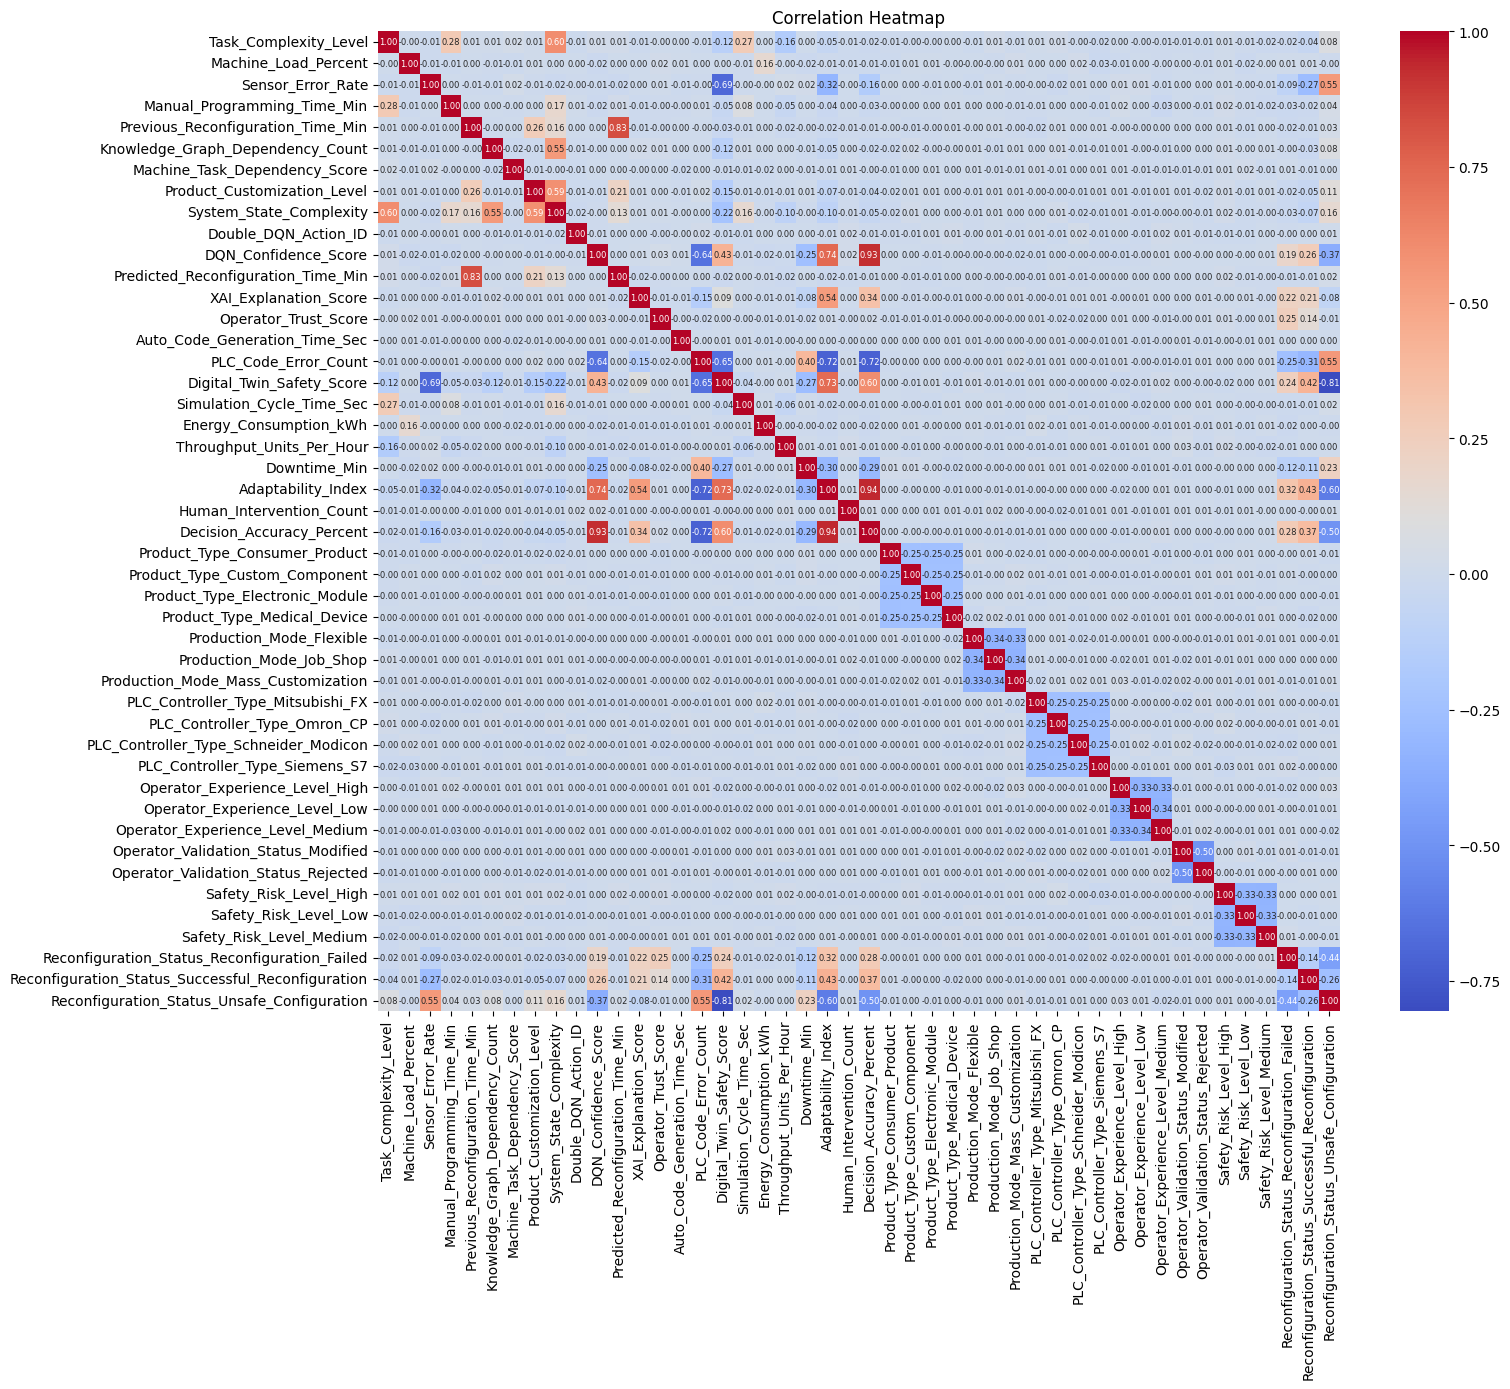

In [60]:
# Making Correlation Matrix
plt.figure(figsize=(16,14))
df_encoded = pd.get_dummies(df, drop_first=True)
corr = df_encoded.select_dtypes(include=[np.number, 'bool']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f", annot_kws={"size": 6})
plt.title("Correlation Heatmap")
plt.savefig('correlation_matrix_dashboard.png',bbox_inches='tight',dpi=300)
plt.tight_layout()

In [71]:
target_corr = corr[['Reconfiguration_Status_Reconfiguration_Failed','Reconfiguration_Status_Successful_Reconfiguration','Reconfiguration_Status_Unsafe_Configuration']]
strong_corr = target_corr[
target_corr.abs() > 0.5
].dropna(how='all')

feature_cols = ~strong_corr.index.isin(['Reconfiguration_Status_Reconfiguration_Failed','Reconfiguration_Status_Successful_Reconfiguration','Reconfiguration_Status_Unsafe_Configuration'])

strong_corr = strong_corr.loc[feature_cols]
strong_columns = strong_corr.index.tolist()

print(strong_columns)

['Sensor_Error_Rate', 'PLC_Code_Error_Count', 'Digital_Twin_Safety_Score', 'Adaptability_Index', 'Decision_Accuracy_Percent']


In [67]:
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
.stack()
.loc[lambda x: x.abs() > 0.5]
)

columns = pairs.index.get_level_values(0).union(
pairs.index.get_level_values(1)
)
corrCols = columns.tolist()
set(corrCols)

{'Adaptability_Index',
 'DQN_Confidence_Score',
 'Decision_Accuracy_Percent',
 'Digital_Twin_Safety_Score',
 'Knowledge_Graph_Dependency_Count',
 'PLC_Code_Error_Count',
 'Predicted_Reconfiguration_Time_Min',
 'Previous_Reconfiguration_Time_Min',
 'Product_Customization_Level',
 'Reconfiguration_Status_Unsafe_Configuration',
 'Sensor_Error_Rate',
 'System_State_Complexity',
 'Task_Complexity_Level',
 'XAI_Explanation_Score'}